Problem 1: Logistic regression

1.1

In [8]:
!pip install ucimlrepo

In [46]:
!pip install --upgrade threadpoolctl


  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 2.2.0
    Uninstalling threadpoolctl-2.2.0:
      Successfully uninstalled threadpoolctl-2.2.0


In [ ]:
!pip install scikit-learn==1.2.2


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [2]:
spambase = fetch_ucirepo(id=94)
X = spambase.data.features
y = spambase.data.targets.values.ravel()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)

accuracy = accuracy_score(y_test, y_pred)
error = 1 - accuracy
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Error:     {error:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

[[651  25]
 [ 55 420]]
Accuracy:  0.9305
Error:     0.0695
Precision: 0.9438
Recall:    0.8842
F1 Score:  0.9130


1.2

In [5]:
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
print(coefs)

print("\nPositively correlated with SPAM:")
print(coefs[coefs > 0].head(10))

print("\nNegatively correlated with SPAM:")
print(coefs[coefs < 0].tail(10))

char_freq_$                   3.507508
word_freq_000                 2.124692
word_freq_remove              2.108740
word_freq_addresses           1.498053
char_freq_#                   1.163484
word_freq_free                1.008440
word_freq_technology          0.984311
word_freq_credit              0.911441
word_freq_business            0.896374
word_freq_3d                  0.759431
word_freq_over                0.659649
word_freq_our                 0.631532
word_freq_order               0.599829
word_freq_internet            0.496107
word_freq_money               0.367724
word_freq_650                 0.336899
word_freq_your                0.241667
word_freq_font                0.233786
char_freq_!                   0.233296
word_freq_415                 0.221062
word_freq_all                 0.141711
word_freq_857                 0.105907
word_freq_you                 0.098307
word_freq_report              0.089078
word_freq_email               0.086463
word_freq_mail           

1.3

In [6]:
thresholds = [0.25, 0.5, 0.75, 0.9]
probs = model.predict_proba(X_test)[:, 1]

for t in thresholds: 
    y_pred_t = (probs>= t).astype(int)
    print(f"T={t}")
    print(f"  Accuracy:  {accuracy_score(y_test, y_pred_t):.4f}")
    print(f"  Precision: {precision_score(y_test, y_pred_t):.4f}")
    print(f"  Recall:    {recall_score(y_test, y_pred_t):.4f}")

T=0.25
  Accuracy:  0.9070
  Precision: 0.8382
  Recall:    0.9600
T=0.5
  Accuracy:  0.9305
  Precision: 0.9438
  Recall:    0.8842
T=0.75
  Accuracy:  0.8862
  Precision: 0.9574
  Recall:    0.7579
T=0.9
  Accuracy:  0.8236
  Precision: 0.9722
  Recall:    0.5895


As the threshold increases, precision goes up, but recall drops. At T=0.25, the model catches more spam with a  recall of 0.96, but it also flags more legit emails as spam with a precision of 0.84. At T=0.9, precision is 0.97, but it misses a lot of actual spam with a recall of 0.59. This is usually seen in a precision-recall tradeoff.

Problem 2 Gradient Descent for Logistic regression

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cross_entropy(y, y_pred):
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)  # avoid log(0)
    return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

def logistic_gradient_descent(X, y, learning_rate, num_iterations):
    n_samples, n_features = X.shape
    theta = np.zeros(n_features)
    
    for i in range(1, num_iterations + 1):
        y_pred = sigmoid(X @ theta)
        gradient = (1/n_samples) * X.T @ (y_pred - y)
        theta = theta - learning_rate * gradient
        
        if i in [10, 50, 100]:
            loss = cross_entropy(y, y_pred)
            print(f"  iter={i}: cross-entropy loss = {loss:.4f}")
    
    return theta

X_train_bias = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_bias  = np.c_[np.ones(X_test_scaled.shape[0]),  X_test_scaled]

learning_rates = [0.01, 0.1, 1.0]

for alpha in learning_rates:
    print(f"\nLearning rate: {alpha}")
    theta = logistic_gradient_descent(X_train_bias, y_train, alpha, 100)
    
    y_train_pred = (sigmoid(X_train_bias @ theta) >= 0.5).astype(int)
    y_test_pred  = (sigmoid(X_test_bias  @ theta) >= 0.5).astype(int)
    
    print(f"  --- Test metrics at iter=100 ---")
    print(f"  Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
    print(f"  Precision: {precision_score(y_test, y_test_pred, zero_division=0):.4f}")
    print(f"  Recall:    {recall_score(y_test, y_test_pred):.4f}")
    print(f"  F1:        {f1_score(y_test, y_test_pred):.4f}")

# compare with sklearn
print("\n--- sklearn ---")
print(f"  Train Accuracy: {accuracy_score(y_train, model.predict(X_train_scaled)):.4f}")
print(f"  Test  Accuracy: {accuracy_score(y_test,  model.predict(X_test_scaled)):.4f}")


Learning rate: 0.01
  iter=10: cross-entropy loss = 0.6550
  iter=50: cross-entropy loss = 0.5436
  iter=100: cross-entropy loss = 0.4698
  --- Test metrics at iter=100 ---
  Accuracy:  0.9036
  Precision: 0.9009
  Recall:    0.8611
  F1:        0.8805

Learning rate: 0.1
  iter=10: cross-entropy loss = 0.4766
  iter=50: cross-entropy loss = 0.3254
  iter=100: cross-entropy loss = 0.2895
  --- Test metrics at iter=100 ---
  Accuracy:  0.9062
  Precision: 0.9238
  Recall:    0.8421
  F1:        0.8811

Learning rate: 1.0
  iter=10: cross-entropy loss = 0.2892
  iter=50: cross-entropy loss = 0.2439
  iter=100: cross-entropy loss = 0.2322
  --- Test metrics at iter=100 ---
  Accuracy:  0.9157
  Precision: 0.9315
  Recall:    0.8589
  F1:        0.8938

--- sklearn ---
  Train Accuracy: 0.9087
  Test  Accuracy: 0.8983


C:\Users\pierr\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\pierr\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Higher learning rates conver faster, a=1.0 reaches a loss of 0.23 by iter=100 while a=0.01 is still at 0.47. All three learning rates produce accuracy and F1 scores within the 3% of the sklearn result. 

Problem 3 Comparing classifiers

3.1

In [15]:
X_train_32 = X_train_scaled.astype(np.float32)
X_val_32 = X_train_scaled.astype(np.float32)

k_values = [1, 3, 5, 7, 11, 15, 21]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    error = 1 - scores.mean()
    print(f"k={k}: accuracy={scores.mean():.4f}, error={error:.4f}")

k=1: accuracy=0.9014, error=0.0986
k=3: accuracy=0.9009, error=0.0991
k=5: accuracy=0.9026, error=0.0974
k=7: accuracy=0.9067, error=0.0933
k=11: accuracy=0.9006, error=0.0994
k=15: accuracy=0.8988, error=0.1012
k=21: accuracy=0.8907, error=0.1093


k=7 has the best accuracy of 0.9067 and lwest error of 0.0933. k=21 has the lowest accuracy.

3.2

In [17]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# train all 3 classifiers
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

log_reg = model

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

classifiers = {'Logistic Regression': log_reg, 'LDA': lda, 'kNN (k=7)': knn}

for name, clf in classifiers.items():
    for split, X, y in [('Train', X_train_scaled, y_train), ('Test', X_test_scaled, y_test)]:
        y_pred = clf.predict(X)
        print(f"{name} [{split}]")
        print(f"  Accuracy:  {accuracy_score(y, y_pred):.4f}")
        print(f"  Error:     {1 - accuracy_score(y, y_pred):.4f}")
        print(f"  Precision: {precision_score(y, y_pred):.4f}")
        print(f"  Recall:    {recall_score(y, y_pred):.4f}")

C:\Users\pierr\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\pierr\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Logistic Regression [Train]
  Accuracy:  0.9087
  Error:     0.0913
  Precision: 0.8968
  Recall:    0.8640
Logistic Regression [Test]
  Accuracy:  0.8983
  Error:     0.1017
  Precision: 0.9032
  Recall:    0.8442
LDA [Train]
  Accuracy:  0.8867
  Error:     0.1133
  Precision: 0.9157
  Recall:    0.7795
LDA [Test]
  Accuracy:  0.8853
  Error:     0.1147
  Precision: 0.9298
  Recall:    0.7811
kNN (k=7) [Train]
  Accuracy:  0.9226
  Error:     0.0774
  Precision: 0.9167
  Recall:    0.8804
kNN (k=7) [Test]
  Accuracy:  0.9018
  Error:     0.0982
  Precision: 0.9114
  Recall:    0.8442


Logistic regression performs the best overall with the highest test accuracy of 0.8983 and best balance of precision and recall. LDA performs worst, with the lowest accuracy and recall on both splits. kNN is competitive on accuracy but shows slight overfitting.

3.3

C:\Users\pierr\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


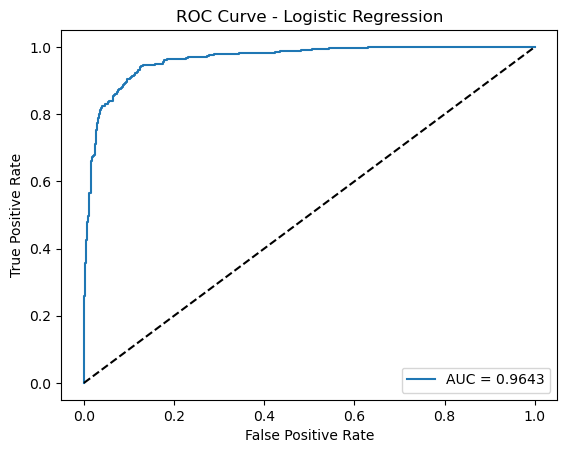

AUC: 0.9643


In [21]:
probs = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

print(f"AUC: {roc_auc:.4f}")

3.4

C:\Users\pierr\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


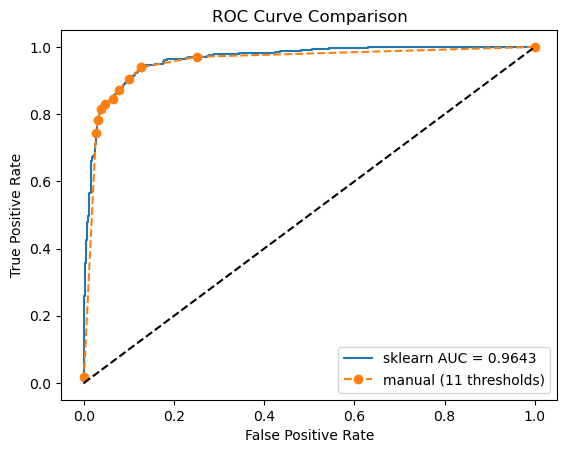

In [23]:
probs = model.predict_proba(X_test_scaled)[:, 1]

thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
fprs, tprs = [], []

for t in thresholds:
    y_pred_t = (probs >= t).astype(int)
    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    tn = ((y_pred_t == 0) & (y_test == 0)).sum()
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()
    tprs.append(tp / (tp + fn))
    fprs.append(fp / (fp + tn))

plt.plot(fpr, tpr, label=f'sklearn AUC = {roc_auc:.4f}')
plt.plot(fprs, tprs, 'o--', label='manual (11 thresholds)')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

both curves follow the same general shape, but the main difference is that the manual curve misses the steep inital rise and priduces straight line segments between points. The sklearn curve is a bit more accurate since it evaluates eveyr possible threshold rather just 11 fixed ones.

Problem 4: Cross validation

4.1

In [25]:
def my_cross_val(clf, X, y, k=5):
    n = len(y)
    fold_size = n // k
    indices = np.arange(n)
    errors = []

    for i in range(k):
        val_idx = indices[i * fold_size:(i + 1) * fold_size]
        train_idx = np.concatenate([indices[:i * fold_size], indices[(i + 1) * fold_size:]])

        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_val)
        errors.append(1 - accuracy_score(y_val, y_pred))

    avg_error = np.mean(errors)
    print(f"Fold errors: {[round(e, 4) for e in errors]}")
    print(f"Average validation error: {avg_error:.4f}")
    return avg_error

print("Logistic Regression:")
my_cross_val(LogisticRegression(max_iter=5000), X_train_scaled, y_train, k=5)

print("\nLDA:")
my_cross_val(LinearDiscriminantAnalysis(), X_train_scaled, y_train, k=5)

Logistic Regression:
Fold errors: [0.0812, 0.0899, 0.0826, 0.0652, 0.0768]
Average validation error: 0.0791

LDA:
Fold errors: [0.1072, 0.1217, 0.1333, 0.0957, 0.1203]
Average validation error: 0.1157


0.11565217391304347

4.2

In [27]:
for k in [5, 10]:
    print(f"k={k} folds:")
    print("  Logistic Regression:", end=" ")
    my_cross_val(LogisticRegression(max_iter=5000), X_train_scaled, y_train, k=k)
    print("  LDA:", end=" ")
    my_cross_val(LinearDiscriminantAnalysis(), X_train_scaled, y_train, k=k)
    print()

k=5 folds:
  Logistic Regression: Fold errors: [0.0812, 0.0899, 0.0826, 0.0652, 0.0768]
Average validation error: 0.0791
  LDA: Fold errors: [0.1072, 0.1217, 0.1333, 0.0957, 0.1203]
Average validation error: 0.1157

k=10 folds:
  Logistic Regression: Fold errors: [0.0754, 0.0812, 0.0986, 0.0783, 0.0754, 0.087, 0.0725, 0.0551, 0.0841, 0.0667]
Average validation error: 0.0774
  LDA: Fold errors: [0.1188, 0.1014, 0.1159, 0.1304, 0.1217, 0.1391, 0.1043, 0.0899, 0.1101, 0.1159]
Average validation error: 0.1148



4.3

Logistic regression outperforms LDA acrross both values of k with a validation error of 0.0791 k=5 and 0.0774 k=10 compared to LDA's 0.1157 and 0.1148. Increasing k from 5 to 10 only slightly improved both models but the gap stays the same. 